## Generar espectros

In [1]:
import gc
import os
import re
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import multirex as mrex
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def remove_warnings() -> None:
    """Suppress DeprecationWarning messages (use cautiously to avoid hiding issues)."""
    warnings.filterwarnings("ignore", category=DeprecationWarning)


waves = np.loadtxt("waves.txt")
n_points = len(waves)

# Note: this builds a full set of indices (0..n_points-1). As written, it effectively
# selects all elements in order; keeping it to preserve behavior.
indices = np.linspace(0, len(waves) - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)

# Select wavelengths using the computed integer indices.
puntos_seleccionados = waves[indices]
waves = puntos_seleccionados

# Wavenumber grid (sorted). Assumes the original intent was 10000 / wavelength.
wn_grid = np.sort(10000 / waves)


Loading MultiREx version 0.3.1


## load data

In [2]:
def apply_contaminations_from_files(contamination_files, df, n_points):
    """
    Apply multiple contaminations to a DataFrame using a list of contamination files.

    The output includes:
    - A non-contaminated case (f_spot = 0.0, f_fac = 0.0)
    - One contaminated copy per file, where the last `n_points` columns are scaled
      by the contamination vector read from that file.

    The file name is expected to encode parameters using:
        fspot<value>_ffac<value>.txt

    Parameters
    ----------
    contamination_files : list of str
        Paths to `.txt` files containing contamination vectors.
    df : pandas.DataFrame
        Original DataFrame to which contaminations will be applied.
    n_points : int
        Number of trailing columns to scale by the contamination vector.

    Returns
    -------
    pandas.DataFrame
        Concatenated DataFrame including the non-contaminated case and all
        contaminations. Three columns are prepended: `contam_source`, `f_spot`,
        and `f_fac`.

    Notes
    -----
    This function attaches two convenience attributes to the returned DataFrame:
    - `df_final.data`: last `n_points` columns
    - `df_final.params`: all other columns
    """
    df_list = []

    # --- Non-contaminated case ---
    df_no_contam = df.copy()
    df_no_contam["contam_source"] = "clean"
    df_no_contam["f_spot"] = 0.0
    df_no_contam["f_fac"] = 0.0

    cols = ["contam_source", "f_spot", "f_fac"] + [
        col
        for col in df_no_contam.columns
        if col not in ["contam_source", "f_spot", "f_fac"]
    ]
    df_no_contam = df_no_contam[cols]
    df_list.append(df_no_contam)

    pattern = r"fspot(?P<f_spot>[0-9.]+)_ffac(?P<f_fac>[0-9.]+)\.txt$"

    for file_path in contamination_files:
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"The file '{file_path}' does not exist.")

        filename = os.path.basename(file_path)
        match = re.search(pattern, filename)
        if not match:
            raise ValueError(
                f"The file name '{filename}' does not match the expected pattern "
                f"'fspot<value>_ffac<value>.txt'."
            )

        contam_source = "sphinx" if filename.startswith("sphinx_") else "original"
        f_spot = float(match.group("f_spot"))
        f_fac = float(match.group("f_fac"))

        try:
            contamination_data = np.loadtxt(file_path, ndmin=2)

            if contamination_data.shape[1] >= 2:
                contam_values = contamination_data[:, 1]
            else:
                contam_values = contamination_data.flatten()

            if len(contam_values) != n_points:
                raise ValueError(
                    f"The number of contamination values in '{filename}' "
                    f"({len(contam_values)}) does not match n_points ({n_points})."
                )
        except Exception as e:
            raise ValueError(f"Error reading the file '{file_path}': {e}") from e

        contam_values = contam_values[::-1]

        df_contam = df.copy()
        data_columns = df_contam.columns[-n_points:]
        df_contam[data_columns] = df_contam[data_columns].multiply(
            contam_values, axis=1
        )

        df_contam["contam_source"] = contam_source
        df_contam["f_spot"] = f_spot
        df_contam["f_fac"] = f_fac
        cols = ["contam_source", "f_spot", "f_fac"] + [
            col
            for col in df_contam.columns
            if col not in ["contam_source", "f_spot", "f_fac"]
        ]
        df_contam = df_contam[cols]
        df_list.append(df_contam)

    df_final = pd.concat(df_list, ignore_index=True)

    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


In [3]:
contamination_dir = "stellar_contamination"
contamination_files = [
    os.path.join(contamination_dir, filename).replace("\\", "/")
    for filename in sorted(
        os.listdir(contamination_dir), key=lambda name: (name.startswith("sphinx_"), name)
    )
    if filename.endswith(".txt") and "TRAPPIST-1_contam_fspot" in filename
]


def filter_rows(df):
    """
    Filter rows where at least one of the target atmospheric columns is >= -8.

    If none of the target columns exist, the DataFrame is returned unchanged.

    Notes
    -----
    This function preserves the original behavior of sequential filtering when
    multiple columns are present (each filter is applied on the result of the
    previous one).
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]

    # Convenience slices for downstream code (kept for compatibility).
    df.data = df.iloc[:, -n_points:]
    df.params = df.iloc[:, :-n_points]

    return df


remove_warnings()

datasets = [
    ("airless_data", "spec_data/airless_data.csv", False),
    ("CO2_data", "spec_data/CO2_data.csv", False),
    ("CH4_data", "spec_data/CH4_data.csv", True),
    ("O3_data", "spec_data/O3_data.csv", True),
    ("H2O_data", "spec_data/H2O_data.csv", True),
    ("CH4_O3_data", "spec_data/CH4_O3_data.csv", True),
    ("CH4_H2O_data", "spec_data/CH4_H2O_data.csv", True),
    ("O3_H2O_data", "spec_data/O3_H2O_data.csv", True),
    ("CH4_O3_H2O_data", "spec_data/CH4_O3_H2O_data.csv", True),
]

for name, path, needs_filter in datasets:
    try:
        df = pd.read_csv(path)

        if needs_filter:
            df = filter_rows(df)

        df = apply_contaminations_from_files(contamination_files, df, n_points)
        globals()[name] = df  # Keep the original variable names in the notebook.
    except Exception as e:
        print(f"Error processing {name}: {e}")

C:\Users\User\AppData\Local\Temp\ipykernel_11028\988470428.py:93: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["contam_source"] = contam_source
C:\Users\User\AppData\Local\Temp\ipykernel_11028\988470428.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_contam["f_spot"] = f_spot
C:\Users\User\AppData\Local\Temp\ipykernel_11028\988470428.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

In [4]:
def normalize_min_max_by_row(df):
    min_by_row = df.min(axis=1)
    max_by_row = df.max(axis=1)
    range_by_row = max_by_row - min_by_row
    # Evitar división por cero asignando NaN, que luego reemplazaremos
    normalized = (df.sub(min_by_row, axis=0)).div(range_by_row, axis=0)
    # Manejar filas donde max == min (rango es cero), puedes ajustar este valor
    normalized[range_by_row == 0] = 0  # O cualquier otro valor que consideres apropiado
    return normalized

## Clean data

In [5]:
def mult_df(df, n_points, n_mult):
    """
    Duplicate a DataFrame `n_mult + 1` times and prepend contamination parameters.

    Each duplicate is a copy of `df` with two added columns:
    - 'f_spot' = 0.0
    - 'f_fac' = 0.0

    The returned DataFrame also exposes two convenience attributes:
    - `.data`: last `n_points` columns
    - `.params`: all remaining columns

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame to duplicate.
    n_points : int
        Number of trailing columns treated as the "data" block.
    n_mult : int
        Number of extra duplicates; total copies will be `n_mult + 1`.

    Returns
    -------
    pandas.DataFrame
        Concatenated DataFrame with `n_mult + 1` copies and 'f_spot'/'f_fac'
        columns placed first.
    """
    df_list = []

    for _ in range(n_mult + 1):
        df_no_contam = df.copy()
        df_no_contam["contam_source"] = "clean"
        df_no_contam["f_spot"] = 0.0
        df_no_contam["f_fac"] = 0.0

        cols = ["contam_source", "f_spot", "f_fac"] + [
            col
            for col in df_no_contam.columns
            if col not in ["contam_source", "f_spot", "f_fac"]
        ]
        df_no_contam = df_no_contam[cols]
        df_list.append(df_no_contam)

    df_final = pd.concat(df_list, ignore_index=True)
    df_final.data = df_final.iloc[:, -n_points:]
    df_final.params = df_final.iloc[:, :-n_points]

    return df_final


In [6]:
def filter_rows(df):
    """
    Filter rows where at least one of the target atmospheric columns is >= -8.

    If none of the target columns exist, the DataFrame is returned unchanged.

    Notes
    -----
    Filtering is applied sequentially for each present column (same behavior as the
    original code).
    """
    filter_columns = ["atm CH4", "atm O3", "atm H2O"]
    present_columns = [col for col in filter_columns if col in df.columns]

    for chem in present_columns:
        df = df[df[chem] >= -8]

    df.data = df.iloc[:, -n_points:]
    df.params = df.iloc[:, :-n_points]

    return df


datasets_clean = [
    ("airless_data_clean", "spec_data/airless_data.csv", False),
    ("CO2_data_clean", "spec_data/CO2_data.csv", False),
    ("CH4_data_clean", "spec_data/CH4_data.csv", True),
    ("O3_data_clean", "spec_data/O3_data.csv", True),
    ("H2O_data_clean", "spec_data/H2O_data.csv", True),
    ("CH4_O3_data_clean", "spec_data/CH4_O3_data.csv", True),
    ("CH4_H2O_data_clean", "spec_data/CH4_H2O_data.csv", True),
    ("O3_H2O_data_clean", "spec_data/O3_H2O_data.csv", True),
    ("CH4_O3_H2O_data_clean", "spec_data/CH4_O3_H2O_data.csv", True),
]

for name, path, needs_filter in datasets_clean:
    try:
        df = pd.read_csv(path)

        if needs_filter:
            df = filter_rows(df)

        df = mult_df(df, n_points, len(contamination_files))
        globals()[name] = df
    except Exception as e:
        print(f"Error processing {name}: {e}")


C:\Users\User\AppData\Local\Temp\ipykernel_11028\764873146.py:45: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_11028\764873146.py:46: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.params = df_final.iloc[:, :-n_points]
C:\Users\User\AppData\Local\Temp\ipykernel_11028\764873146.py:45: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_final.data = df_final.iloc[:, -n_points:]
C:\Users\User\AppData\Local\Temp\ipykernel_11028\764873146.py:46: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.py

# Noise


In [7]:
def generate_df_with_noise_std(df, n_repeat, noise_std, seed=None):
    """
    Generate a new DataFrame by replicating spectra and adding Gaussian noise.

    The input DataFrame is expected to expose:
    - `df.params`: parameters (DataFrame)
    - `df.data`: spectra (DataFrame)

    If `df.params` is missing, an empty parameter DataFrame is assumed. If both
    `df.params` and `df.data` are missing, the entire `df` is treated as spectra.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with `.params` and `.data` attributes (preferred).
    n_repeat : int
        Number of times each spectrum is replicated.
    noise_std : int | float | list | numpy.ndarray | pandas.Series
        Noise standard deviation. Either a scalar applied to all spectra, or an
        array-like with one value per input spectrum.
    seed : int | None, optional
        RNG seed for reproducibility.

    Returns
    -------
    pandas.DataFrame
        Concatenated DataFrame with replicated parameters and noisy spectra.
        The returned DataFrame includes `.params` and `.data` attributes.
    """
    # --- Resolve input layout: df.params / df.data ---
    if not hasattr(df, "params"):
        print("Warning: 'params' attribute not found in the DataFrame.")
        df_params = pd.DataFrame()

        if not hasattr(df, "data"):
            print(
                "Warning: 'data' attribute not found in the DataFrame. "
                "Assuming the DataFrame contains only spectra."
            )
            df_spectra = df
        else:
            df_spectra = df.data
    else:
        if not hasattr(df, "data"):
            raise ValueError("The DataFrame must have a 'data' attribute.")
        df_params = df.params
        df_spectra = df.data

    # --- Validate inputs ---
    if not isinstance(df_spectra, pd.DataFrame):
        raise ValueError("df_spectra must be a pandas DataFrame.")
    if not isinstance(df_params, pd.DataFrame):
        raise ValueError("df_params must be a pandas DataFrame.")
    if not isinstance(n_repeat, int) or n_repeat <= 0:
        raise ValueError("n_repeat must be a positive integer.")

    if isinstance(noise_std, (int, float)):
        if noise_std < 0:
            raise ValueError("noise_std must be a non-negative number.")
    elif isinstance(noise_std, (list, np.ndarray, pd.Series)):
        if not all(n >= 0 for n in noise_std):
            raise ValueError("All values in noise_std must be non-negative.")
        if len(noise_std) != len(df_spectra):
            raise ValueError(
                "Length of noise_std must match the number of spectra in df."
            )
    else:
        raise ValueError(
            "noise_std must be a non-negative number or a list/array of "
            "non-negative numbers."
        )

    if seed is not None and (not isinstance(seed, int) or seed < 0):
        raise ValueError("seed must be a non-negative integer.")

    # --- RNG seeding ---
    if seed is not None:
        np.random.seed(seed)

    # --- Replicate spectra rows ---
    df_spectra_replicated = pd.DataFrame(
        np.repeat(df_spectra.values, n_repeat, axis=0),
        columns=df_spectra.columns,
    )

    # --- Expand noise_std to match replicated spectra shape ---
    if isinstance(noise_std, (int, float)):
        noise_replicated = np.full(df_spectra_replicated.shape, noise_std)
    else:
        noise_array = np.array(noise_std)
        noise_replicated = np.repeat(noise_array[:, np.newaxis], n_repeat, axis=0)
        noise_replicated = np.tile(
            noise_replicated, (1, df_spectra_replicated.shape[1])
        )

    # --- Apply Gaussian noise (vectorized) ---
    gaussian_noise = np.random.normal(
        loc=0.0,
        scale=noise_replicated,
        size=df_spectra_replicated.shape,
    )
    df_spectra_replicated += gaussian_noise

    # --- Replicate parameters to align with spectra ---
    df_params_replicated = pd.DataFrame(
        np.repeat(df_params.values, n_repeat, axis=0),
        columns=df_params.columns,
    )

    # --- Insert metadata columns into params ---
    if isinstance(noise_std, (int, float)):
        df_params_replicated.insert(0, "noise_std", noise_std)
    else:
        df_params_replicated.insert(0, "noise_std", np.repeat(noise_std, n_repeat))
    df_params_replicated.insert(1, "n_repeat", n_repeat)

    # --- Concatenate params + spectra ---
    df_final = pd.concat(
        [
            df_params_replicated.reset_index(drop=True),
            df_spectra_replicated.reset_index(drop=True),
        ],
        axis=1,
    )

    # --- Set .data and .params attributes (local warnings suppression) ---
    warnings.filterwarnings("ignore")
    df_final.data = df_final.iloc[:, -df_spectra_replicated.shape[1] :]
    df_final.params = df_final.iloc[:, : df_params_replicated.shape[1]]
    warnings.filterwarnings("default")

    return df_final


## SNR = 1


In [ ]:
# Use CO2_data as reference to obtain a wavelength-dependent noise vector.
noise = mrex.generate_df_SNR_noise(df=CO2_data, n_repeat=1, SNR=1)["noise"][1]

snr_repeat_map = {
    "CO2": 2_000,
    "CH4": 200,
    "O3": 200,
    "H2O": 200,
    "CH4_O3": 20,
    "CH4_H2O": 20,
    "O3_H2O": 20,
    "CH4_O3_H2O": 4,
    "airless": 2_000,
}

snr_df_map = {
    "CO2": CO2_data,
    "CH4": CH4_data,
    "O3": O3_data,
    "H2O": H2O_data,
    "CH4_O3": CH4_O3_data,
    "CH4_H2O": CH4_H2O_data,
    "O3_H2O": O3_H2O_data,
    "CH4_O3_H2O": CH4_O3_H2O_data,
    "airless": airless_data,
}

snr_clean_df_map = {
    "CO2": CO2_data_clean,
    "CH4": CH4_data_clean,
    "O3": O3_data_clean,
    "H2O": H2O_data_clean,
    "CH4_O3": CH4_O3_data_clean,
    "CH4_H2O": CH4_H2O_data_clean,
    "O3_H2O": O3_H2O_data_clean,
    "CH4_O3_H2O": CH4_O3_H2O_data_clean,
    "airless": airless_data_clean,
}

# Build noisy datasets (contaminated).
snr_noisy_products = {}
for key, df in snr_df_map.items():
    snr_noisy_products[key] = generate_df_with_noise_std(
        df=df,
        n_repeat=snr_repeat_map[key],
        noise_std=noise,
    )

SNR1_df = pd.concat(list(snr_noisy_products.values()), ignore_index=True)

# Free memory aggressively (optional but consistent with your workflow).
del snr_noisy_products
gc.collect()

# Build clean/no-noise datasets (noise_std = 0).
snr_clean_products = {}
for key, df in snr_clean_df_map.items():
    snr_clean_products[key] = generate_df_with_noise_std(
        df=df,
        n_repeat=snr_repeat_map[key],
        noise_std=0,
    )

SNR1_no_df = pd.concat(list(snr_clean_products.values()), ignore_index=True)

del snr_clean_products
gc.collect()

print("Clean and noise dataframes have the same shape:", SNR1_df.shape == SNR1_no_df.shape)


Clean and noise dataframes have the same shape: True


## SNR = 3

In [9]:
noise = mrex.generate_df_SNR_noise(df=CO2_data, n_repeat=1, SNR=3)["noise"][1]

snr_repeat_map = {
    "CO2": 2_000,
    "CH4": 200,
    "O3": 200,
    "H2O": 200,
    "CH4_O3": 20,
    "CH4_H2O": 20,
    "O3_H2O": 20,
    "CH4_O3_H2O": 4,
    "airless": 2_000,
}

snr_df_map = {
    "CO2": CO2_data,
    "CH4": CH4_data,
    "O3": O3_data,
    "H2O": H2O_data,
    "CH4_O3": CH4_O3_data,
    "CH4_H2O": CH4_H2O_data,
    "O3_H2O": O3_H2O_data,
    "CH4_O3_H2O": CH4_O3_H2O_data,
    "airless": airless_data,
}

snr_clean_df_map = {
    "CO2": CO2_data_clean,
    "CH4": CH4_data_clean,
    "O3": O3_data_clean,
    "H2O": H2O_data_clean,
    "CH4_O3": CH4_O3_data_clean,
    "CH4_H2O": CH4_H2O_data_clean,
    "O3_H2O": O3_H2O_data_clean,
    "CH4_O3_H2O": CH4_O3_H2O_data_clean,
    "airless": airless_data_clean,
}

snr_noisy_products = {}
for key, df in snr_df_map.items():
    snr_noisy_products[key] = generate_df_with_noise_std(
        df=df,
        n_repeat=snr_repeat_map[key],
        noise_std=noise,
    )

SNR3_df = pd.concat(list(snr_noisy_products.values()), ignore_index=True)

del snr_noisy_products
gc.collect()

snr_clean_products = {}
for key, df in snr_clean_df_map.items():
    snr_clean_products[key] = generate_df_with_noise_std(
        df=df,
        n_repeat=snr_repeat_map[key],
        noise_std=0,
    )

SNR3_no_df = pd.concat(list(snr_clean_products.values()), ignore_index=True)

del snr_clean_products
gc.collect()

print("Clean and noise dataframes have the same shape:", SNR3_df.shape == SNR3_no_df.shape)


Clean and noise dataframes have the same shape: True


## SNR = 6

In [10]:
noise = mrex.generate_df_SNR_noise(df=CO2_data, n_repeat=1, SNR=6)["noise"][1]

snr_repeat_map = {
    "CO2": 1_500,
    "CH4": 150,
    "O3": 150,
    "H2O": 150,
    "CH4_O3": 15,
    "CH4_H2O": 15,
    "O3_H2O": 15,
    "CH4_O3_H2O": 3,
    "airless": 1_500,
}

snr_df_map = {
    "CO2": CO2_data,
    "CH4": CH4_data,
    "O3": O3_data,
    "H2O": H2O_data,
    "CH4_O3": CH4_O3_data,
    "CH4_H2O": CH4_H2O_data,
    "O3_H2O": O3_H2O_data,
    "CH4_O3_H2O": CH4_O3_H2O_data,
    "airless": airless_data,
}

snr_clean_df_map = {
    "CO2": CO2_data_clean,
    "CH4": CH4_data_clean,
    "O3": O3_data_clean,
    "H2O": H2O_data_clean,
    "CH4_O3": CH4_O3_data_clean,
    "CH4_H2O": CH4_H2O_data_clean,
    "O3_H2O": O3_H2O_data_clean,
    "CH4_O3_H2O": CH4_O3_H2O_data_clean,
    "airless": airless_data_clean,
}

snr_noisy_products = {}
for key, df in snr_df_map.items():
    snr_noisy_products[key] = generate_df_with_noise_std(
        df=df,
        n_repeat=snr_repeat_map[key],
        noise_std=noise,
    )

SNR6_df = pd.concat(list(snr_noisy_products.values()), ignore_index=True)

del snr_noisy_products
gc.collect()

snr_clean_products = {}
for key, df in snr_clean_df_map.items():
    snr_clean_products[key] = generate_df_with_noise_std(
        df=df,
        n_repeat=snr_repeat_map[key],
        noise_std=0,
    )

SNR6_no_df = pd.concat(list(snr_clean_products.values()), ignore_index=True)

del snr_clean_products
gc.collect()

print("Clean and noise dataframes have the same shape:", SNR6_df.shape == SNR6_no_df.shape)


Clean and noise dataframes have the same shape: True


## SNR = 10

In [11]:
noise = mrex.generate_df_SNR_noise(df=CO2_data, n_repeat=1, SNR=10)["noise"][1]

snr_repeat_map = {
    "CO2": 1_000,
    "CH4": 100,
    "O3": 100,
    "H2O": 100,
    "CH4_O3": 10,
    "CH4_H2O": 10,
    "O3_H2O": 10,
    "CH4_O3_H2O": 2,
    "airless": 1_000,
}

snr_df_map = {
    "CO2": CO2_data,
    "CH4": CH4_data,
    "O3": O3_data,
    "H2O": H2O_data,
    "CH4_O3": CH4_O3_data,
    "CH4_H2O": CH4_H2O_data,
    "O3_H2O": O3_H2O_data,
    "CH4_O3_H2O": CH4_O3_H2O_data,
    "airless": airless_data,
}

snr_clean_df_map = {
    "CO2": CO2_data_clean,
    "CH4": CH4_data_clean,
    "O3": O3_data_clean,
    "H2O": H2O_data_clean,
    "CH4_O3": CH4_O3_data_clean,
    "CH4_H2O": CH4_H2O_data_clean,
    "O3_H2O": O3_H2O_data_clean,
    "CH4_O3_H2O": CH4_O3_H2O_data_clean,
    "airless": airless_data_clean,
}

snr_noisy_products = {}
for key, df in snr_df_map.items():
    snr_noisy_products[key] = generate_df_with_noise_std(
        df=df,
        n_repeat=snr_repeat_map[key],
        noise_std=noise,
    )

SNR10_df = pd.concat(list(snr_noisy_products.values()), ignore_index=True)

del snr_noisy_products
gc.collect()

snr_clean_products = {}
for key, df in snr_clean_df_map.items():
    snr_clean_products[key] = generate_df_with_noise_std(
        df=df,
        n_repeat=snr_repeat_map[key],
        noise_std=0,
    )

SNR10_no_df = pd.concat(list(snr_clean_products.values()), ignore_index=True)

del snr_clean_products
gc.collect()

print("Clean and noise dataframes have the same shape:", SNR10_df.shape == SNR10_no_df.shape)


Clean and noise dataframes have the same shape: True


## SNR = Nan

In [12]:
# --- (noise_std = 0) ---

SNRNan_CO2_data = generate_df_with_noise_std(
    df=CO2_data,
    n_repeat=3_000,
    noise_std=0,
)

SNRNan_CH4_data = generate_df_with_noise_std(
    df=CH4_data,
    n_repeat=300,
    noise_std=0,
)

SNRNan_O3_data = generate_df_with_noise_std(
    df=O3_data,
    n_repeat=300,
    noise_std=0,
)

SNRNan_H2O_data = generate_df_with_noise_std(
    df=H2O_data,
    n_repeat=300,
    noise_std=0,
)

SNRNan_CH4_O3_data = generate_df_with_noise_std(
    df=CH4_O3_data,
    n_repeat=30,
    noise_std=0,
)

SNRNan_CH4_H2O_data = generate_df_with_noise_std(
    df=CH4_H2O_data,
    n_repeat=30,
    noise_std=0,
)

SNRNan_O3_H2O_data = generate_df_with_noise_std(
    df=O3_H2O_data,
    n_repeat=30,
    noise_std=0,
)

SNRNan_CH4_O3_H2O_data = generate_df_with_noise_std(
    df=CH4_O3_H2O_data,
    n_repeat=5,
    noise_std=0,
)

SNRNan_airless_data = generate_df_with_noise_std(
    df=airless_data,
    n_repeat=4_000,
    noise_std=0,
)

SNRNan_df = pd.concat(
    [
        SNRNan_CO2_data,
        SNRNan_CH4_data,
        SNRNan_O3_data,
        SNRNan_H2O_data,
        SNRNan_CH4_O3_data,
        SNRNan_CH4_H2O_data,
        SNRNan_O3_H2O_data,
        SNRNan_CH4_O3_H2O_data,
        SNRNan_airless_data,
    ],
    ignore_index=True,
)

del (
    SNRNan_CO2_data,
    SNRNan_CH4_data,
    SNRNan_O3_data,
    SNRNan_H2O_data,
    SNRNan_CH4_O3_data,
    SNRNan_CH4_H2O_data,
    SNRNan_O3_H2O_data,
    SNRNan_CH4_O3_H2O_data,
    SNRNan_airless_data,
)

# --- Clean counterparts (also noise_std = 0) ---
SNRNan_no_CO2_data = generate_df_with_noise_std(
    df=CO2_data_clean,
    n_repeat=3_000,
    noise_std=0,
)

SNRNan_no_CH4_data = generate_df_with_noise_std(
    df=CH4_data_clean,
    n_repeat=300,
    noise_std=0,
)

SNRNan_no_O3_data = generate_df_with_noise_std(
    df=O3_data_clean,
    n_repeat=300,
    noise_std=0,
)

SNRNan_no_H2O_data = generate_df_with_noise_std(
    df=H2O_data_clean,
    n_repeat=300,
    noise_std=0,
)

SNRNan_no_CH4_O3_data = generate_df_with_noise_std(
    df=CH4_O3_data_clean,
    n_repeat=30,
    noise_std=0,
)

SNRNan_no_CH4_H2O_data = generate_df_with_noise_std(
    df=CH4_H2O_data_clean,
    n_repeat=30,
    noise_std=0,
)

SNRNan_no_O3_H2O_data = generate_df_with_noise_std(
    df=O3_H2O_data_clean,
    n_repeat=30,
    noise_std=0,
)

SNRNan_no_CH4_O3_H2O_data = generate_df_with_noise_std(
    df=CH4_O3_H2O_data_clean,
    n_repeat=5,
    noise_std=0,
)

SNRNan_no_airless_data = generate_df_with_noise_std(
    df=airless_data_clean,
    n_repeat=4_000,
    noise_std=0,
)

SNRNan_no_df = pd.concat(
    [
        SNRNan_no_CO2_data,
        SNRNan_no_CH4_data,
        SNRNan_no_O3_data,
        SNRNan_no_H2O_data,
        SNRNan_no_CH4_O3_data,
        SNRNan_no_CH4_H2O_data,
        SNRNan_no_O3_H2O_data,
        SNRNan_no_CH4_O3_H2O_data,
        SNRNan_no_airless_data,
    ],
    ignore_index=True,
)

del (
    SNRNan_no_CO2_data,
    SNRNan_no_CH4_data,
    SNRNan_no_O3_data,
    SNRNan_no_H2O_data,
    SNRNan_no_CH4_O3_data,
    SNRNan_no_CH4_H2O_data,
    SNRNan_no_O3_H2O_data,
    SNRNan_no_CH4_O3_H2O_data,
    SNRNan_no_airless_data,
)

gc.collect()

print("Clean and noise dataframes have the same shape:", SNRNan_df.shape == SNRNan_no_df.shape)


Clean and noise dataframes have the same shape: True


## Data 

In [13]:
# Noisy data
##-------------
# Concatenate noisy DataFrames and convert labels from string to list
SNRall_noisy = pd.concat(
    [SNR1_df, SNR3_df, SNR6_df, SNR10_df, SNRNan_df], ignore_index=True
)

# Free memory from individual noisy DataFrames
del SNR1_df, SNR3_df, SNR6_df, SNR10_df, SNRNan_df
gc.collect()

# Normalize the last n_points columns row-wise
SNRall_noisy.iloc[:, -n_points:] = normalize_min_max_by_row(
    SNRall_noisy.iloc[:, -n_points:]
)
X_noisy = SNRall_noisy.iloc[:, -n_points:].values

##-------------
# Clean data
# Concatenate non-noisy DataFrames and convert labels
SNRall_no_noisy = pd.concat(
    [SNR1_no_df, SNR3_no_df, SNR6_no_df, SNR10_no_df, SNRNan_no_df], ignore_index=True
)

# Free memory from individual clean DataFrames
del SNR1_no_df, SNR3_no_df, SNR6_no_df, SNR10_no_df, SNRNan_no_df
gc.collect()

# Normalize the last n_points columns row-wise
SNRall_no_noisy.iloc[:, -n_points:] = normalize_min_max_by_row(
    SNRall_no_noisy.iloc[:, -n_points:]
)
X_no_noisy = SNRall_no_noisy.iloc[:, -n_points:].values

# Ensure the number of samples match
assert SNRall_noisy.shape[0] == SNRall_no_noisy.shape[0], (
    "The number of samples does not match between X_noisy and X_clean."
)

# Clean up variables and force garbage collection
del SNRall_noisy, SNRall_no_noisy
gc.collect()

0

### FInal data

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


<frozen importlib._bootstrap>:488: DeprecationWarning: Type google.protobuf.pyext._message.ScalarMapContainer uses PyType_Spec with a metaclass that has custom tp_new. This is deprecated and will no longer be allowed in Python 3.14.
<frozen importlib._bootstrap>:488: DeprecationWarning: Type google.protobuf.pyext._message.MessageMapContainer uses PyType_Spec with a metaclass that has custom tp_new. This is deprecated and will no longer be allowed in Python 3.14.


In [15]:
test_size = 0.2

X_train_noisy, X_test_noisy, X_train_clean, X_test_clean = train_test_split(
    X_noisy,
    X_no_noisy,
    test_size=test_size,
)

del X_noisy, X_no_noisy
gc.collect()


4

### Autoencoder 

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

input_dim = X_train_noisy.shape[1]
l2_lambda = 1e-7

assert input_dim in {n_points, 2 * n_points}, (
    f"Unexpected input_dim={input_dim}. Expected n_points={n_points} "
    f"or 2*n_points={2 * n_points}."
)

input_spectrum = keras.Input(shape=(input_dim,))

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(input_spectrum)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

encoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
encoded = layers.Dropout(0.5)(encoded)

decoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(encoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    300,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

decoded = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=keras.regularizers.l2(l2_lambda),
)(decoded)
decoded = layers.Dropout(0.5)(decoded)

output = layers.Dense(n_points, activation="linear")(decoded)

autoencoder = keras.Model(inputs=input_spectrum, outputs=output)

optimizer = Adam(learning_rate=1e-5)
autoencoder.compile(optimizer=optimizer, loss="mae")

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 385)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       153,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       154,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 385)            │       197,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,024,673 (7.72 MB)

 Trainable params: 2,024,673 (7.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 439s 10ms/step - loss: 0.1264 - val_loss: 0.0723
Epoch 2/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 419s 9ms/step - loss: 0.0798 - val_loss: 0.0540
Epoch 3/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 420s 9ms/step - loss: 0.0660 - val_loss: 0.0466
Epoch 4/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 422s 9ms/step - loss: 0.0581 - val_loss: 0.0407
Epoch 5/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 421s 9ms/step - loss: 0.0520 - val_loss: 0.0353
Epoch 6/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 419s 9ms/step - loss: 0.0472 - val_loss: 0.0326
Epoch 7/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 421s 9ms/step - loss: 0.0442 - val_loss: 0.0301
Epoch 8/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 423s 9ms/step - loss: 0.0418 - val_loss: 0.0286
Epoch 9/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 422s 9ms/step - loss: 0.0405 - val_loss: 0.0272
Epoch 10/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 421s 9ms/step - loss: 0.0393 - val_loss: 0.0263
Epoch 11/100
45070/45070 ━━━━━━━━━━━━━━━━━━━━ 422s 9ms/step - loss: 

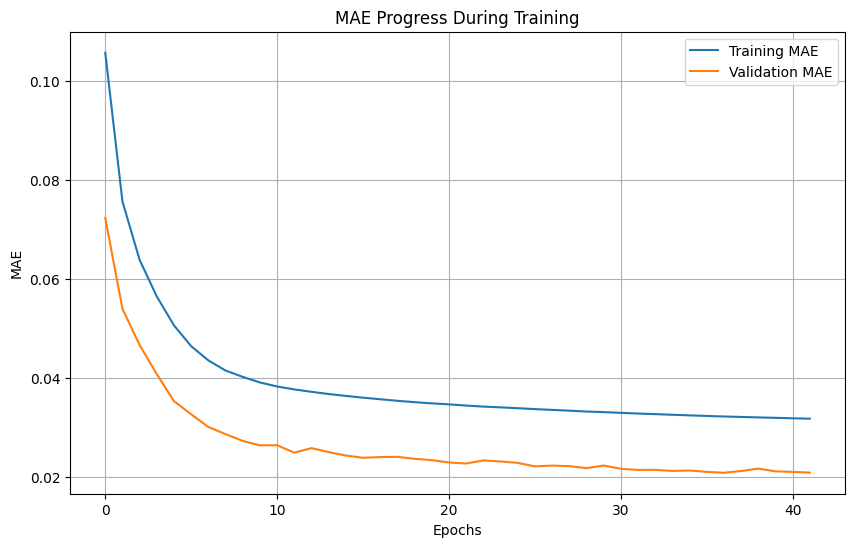

22535/22535 ━━━━━━━━━━━━━━━━━━━━ 89s 4ms/step


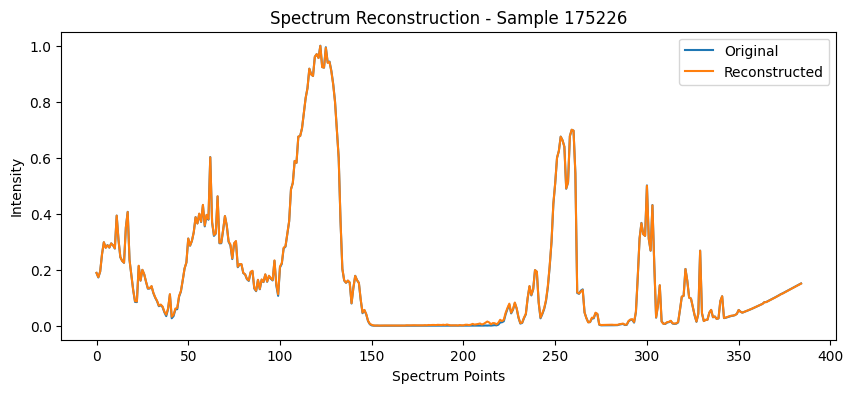

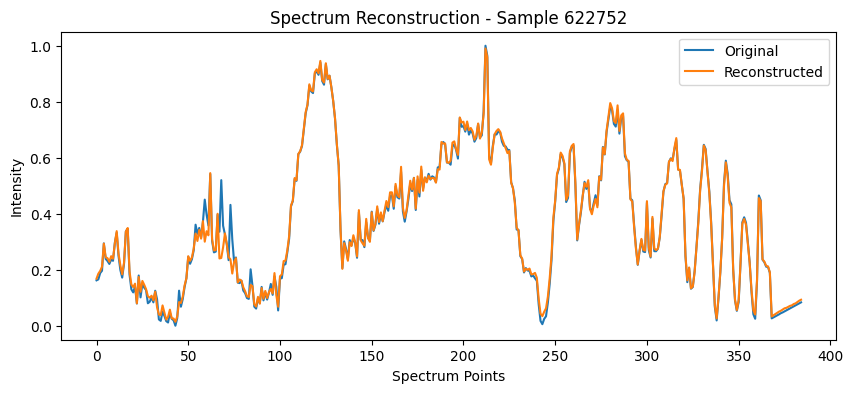

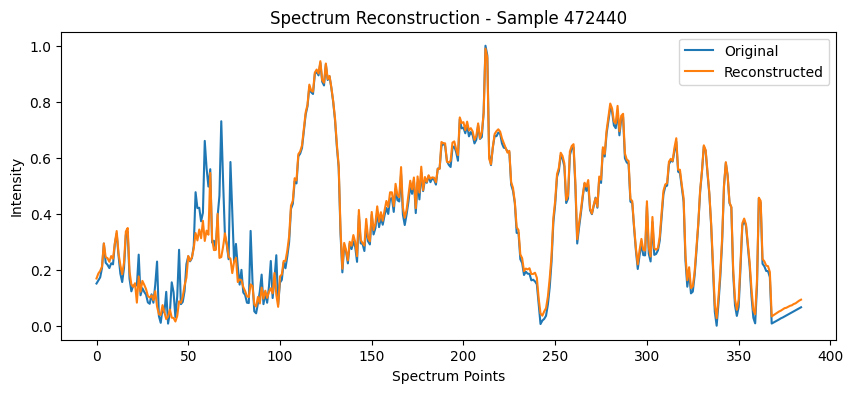

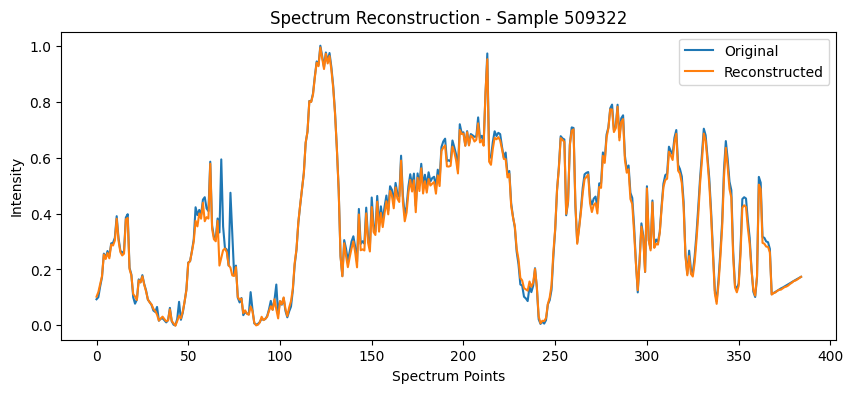

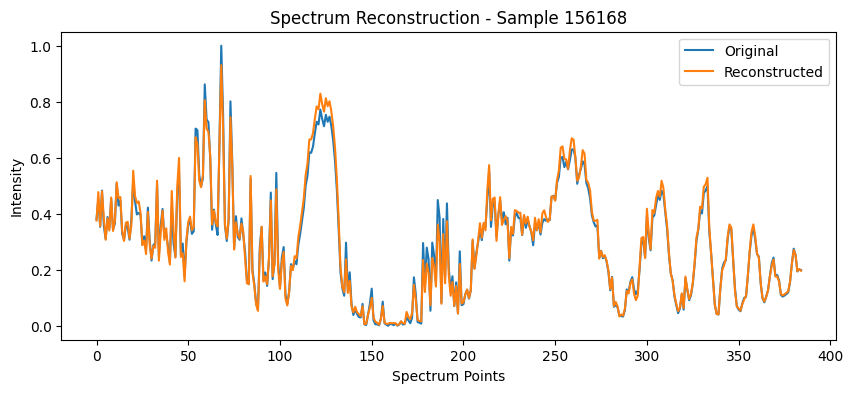

In [17]:
# Train the autoencoder
history = autoencoder.fit(
    X_train_noisy,
    X_train_clean,
    epochs=100,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test_noisy, X_test_clean),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ],
)

# Save the trained model
autoencoder.save("Models/G-DAE.keras")

# Plot training and validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training MAE")
plt.plot(history.history["val_loss"], label="Validation MAE")
plt.title("MAE Progress During Training")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

# Predict reconstructed spectra on test data
decoded_spectra = autoencoder.predict(X_test_noisy)

# Visualize a few reconstructions
num_samples = 5  # Number of samples to visualize
indices = np.random.choice(len(X_test_noisy), num_samples, replace=False)

for idx in indices:
    plt.figure(figsize=(10, 4))
    plt.plot(X_test_clean[idx].flatten(), label="Original")
    plt.plot(decoded_spectra[idx].flatten(), label="Reconstructed")
    plt.xlabel("Spectrum Points")
    plt.ylabel("Intensity")
    plt.title(f"Spectrum Reconstruction - Sample {idx}")
    plt.legend()
    plt.show()


# Eval

In [18]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras

# Load the trained autoencoder model and reconstruct the test spectra
autoencoder = keras.models.load_model("Models/G-DAE.keras")

X_reconstructed = autoencoder.predict(X_test_noisy)

# Compute evaluation metrics on the test set
mae = mean_absolute_error(X_test_clean, X_reconstructed)
print(f"Mean Absolute Error (MAE): {mae:.6f}")

mse = mean_squared_error(X_test_clean, X_reconstructed)
print(f"Mean Squared Error (MSE): {mse:.6f}")

r2 = r2_score(X_test_clean, X_reconstructed)
print(f"Coefficient of Determination (R²): {r2:.6f}")

22535/22535 ━━━━━━━━━━━━━━━━━━━━ 85s 4ms/step
Mean Absolute Error (MAE): 0.020434
Mean Squared Error (MSE): 0.002958
Coefficient of Determination (R²): 0.898068


## plot

In [19]:
noise =  mrex.generate_df_SNR_noise(
    df=CO2_data,
    n_repeat=1,
    SNR=3     
)["noise"][1]


SNR3_CO2_data = generate_df_with_noise_std(
    df=CO2_data,
    n_repeat=10_000,
    noise_std = noise     
)

SNR3_CH4_data = generate_df_with_noise_std(
    df=CH4_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_O3_data = generate_df_with_noise_std(
    df=O3_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_H2O_data = generate_df_with_noise_std(
    df=H2O_data,
    n_repeat=250,
    noise_std = noise     
)

SNR3_CH4_O3_data = generate_df_with_noise_std(
    df=CH4_O3_data,
    n_repeat=350, # 350 for graph
    noise_std = noise
)

SNR3_CH4_H2O_data = generate_df_with_noise_std(
    df=CH4_H2O_data,
    n_repeat=30,
    noise_std = noise
)

SNR3_O3_H2O_data = generate_df_with_noise_std(
    df=O3_H2O_data,
    n_repeat=30,
    noise_std = noise
)

SNR3_CH4_O3_H2O_data = generate_df_with_noise_std(
    df=CH4_O3_H2O_data,
    n_repeat=5,
    noise_std = noise
)
    
SNR3_airless_data = generate_df_with_noise_std(
    df=airless_data,
    n_repeat=10_000,
    noise_std = noise   
)

SNR3_df = pd.concat(
    [
        SNR3_CO2_data,
        SNR3_CH4_data,
        SNR3_O3_data,
        SNR3_H2O_data,
        SNR3_CH4_O3_data,
        SNR3_CH4_H2O_data,
        SNR3_O3_H2O_data,
        SNR3_CH4_O3_H2O_data,
        SNR3_airless_data
    ],
    ignore_index=True
) 


del (
        SNR3_CO2_data,
        SNR3_CH4_data,
        SNR3_O3_data,
        SNR3_H2O_data,
        SNR3_CH4_O3_data,
        SNR3_CH4_H2O_data,
        SNR3_O3_H2O_data,
        SNR3_CH4_O3_H2O_data,
        SNR3_airless_data
        
)

gc.collect()


327

In [20]:
# Display the first few rows (for quick sanity check).
SNR3_df.head()

# Filter the DataFrame for a specific stellar contamination configuration.
target_contam_source = "original"
auto_SNR3_df = SNR3_df[
    (SNR3_df["contam_source"] == target_contam_source)
    & (SNR3_df["f_spot"] == 0.08)
    & (SNR3_df["f_fac"] == 0.54)
].copy()

# Normalize the spectral block (last n_points columns) row-wise.
auto_SNR3_df.iloc[:, -n_points:] = normalize_min_max_by_row(
    auto_SNR3_df.iloc[:, -n_points:]
)

# Predict the encoded representation (assumes `autoencoder` is already defined/loaded).
X = auto_SNR3_df.iloc[:, -n_points:].values
X = autoencoder.predict(X)

# Store the encoded output back into a copy of the original DataFrame.
auto_reconstructed_SNR3_df = auto_SNR3_df.copy()
auto_reconstructed_SNR3_df.iloc[:, -n_points:] = X

# Non-atmospheric CO2 example (atm CO2 == 0).
airless_SNR3 = auto_SNR3_df[auto_SNR3_df["atm CO2"] == 0].iloc[1, -n_points:].values
airless_reconstructed_SNR3 = auto_reconstructed_SNR3_df[
    auto_reconstructed_SNR3_df["atm CO2"] == 0
].iloc[1, -n_points:].values

# Clean reference for the airless case.
airless_clean_df = airless_data[airless_data["f_spot"] == 0.0].copy()
airless_clean_df.iloc[:, -n_points:] = normalize_min_max_by_row(
    airless_clean_df.iloc[:, -n_points:]
)
airless_clean = airless_clean_df.iloc[0, -n_points:].values

# CO2 analysis: select a row index `i` under CH4=O3=H2O=0.
i = 96
print(f"CO2 = {i}")

CO2_SNR3_df = auto_SNR3_df[
    (auto_SNR3_df["atm CH4"] == 0)
    & (auto_SNR3_df["atm O3"] == 0)
    & (auto_SNR3_df["atm H2O"] == 0)
].iloc[i, -n_points:].values

CO2_reconstructed_SNR3 = auto_reconstructed_SNR3_df[
    (auto_reconstructed_SNR3_df["atm CH4"] == 0)
    & (auto_reconstructed_SNR3_df["atm O3"] == 0)
    & (auto_reconstructed_SNR3_df["atm H2O"] == 0)
].iloc[i, -n_points:].values

CO2_clean_df = CO2_data[CO2_data["f_spot"] == 0.0].copy()
CO2_clean_df.iloc[:, -n_points:] = normalize_min_max_by_row(
    CO2_clean_df.iloc[:, -n_points:]
)
CO2_clean = CO2_clean_df.iloc[1, -n_points:].values

# Biosignature analysis: select a row index `i` for specific CH4/O3/H2O values.
i = 185
print(f"bio = {i}")

bio_SNR3_df = auto_SNR3_df[
    (auto_SNR3_df["atm CH4"] == -5)
    & (auto_SNR3_df["atm O3"] == -7)
    & (auto_SNR3_df["atm H2O"] == 0)
].iloc[i, -n_points:]

bio_reconstructed_SNR3 = auto_reconstructed_SNR3_df[
    (auto_reconstructed_SNR3_df["atm CH4"] == -5)
    & (auto_reconstructed_SNR3_df["atm O3"] == -7)
    & (auto_reconstructed_SNR3_df["atm H2O"] == 0)
].iloc[i, -n_points:]

bio_clean_df = CH4_O3_data[
    (CH4_O3_data["f_spot"] == 0.0)
    & (CH4_O3_data["f_fac"] == 0.0)
    & (CH4_O3_data["atm CH4"] == -5)
    & (CH4_O3_data["atm O3"] == -7)
    & (CH4_O3_data["atm H2O"] == 0)
].copy()
bio_clean_df.iloc[:, -n_points:] = normalize_min_max_by_row(
    bio_clean_df.iloc[:, -n_points:]
)
bio_clean = bio_clean_df.iloc[1, -n_points:].values

X_clean = [airless_clean, CO2_clean, bio_clean]
X_noisy = [airless_SNR3, CO2_SNR3_df, bio_SNR3_df]
X_reconstructed = [
    airless_reconstructed_SNR3,
    CO2_reconstructed_SNR3,
    bio_reconstructed_SNR3,
]


4513/4513 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step
CO2 = 96
bio = 185


In [21]:
import matplotlib as mpl


mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

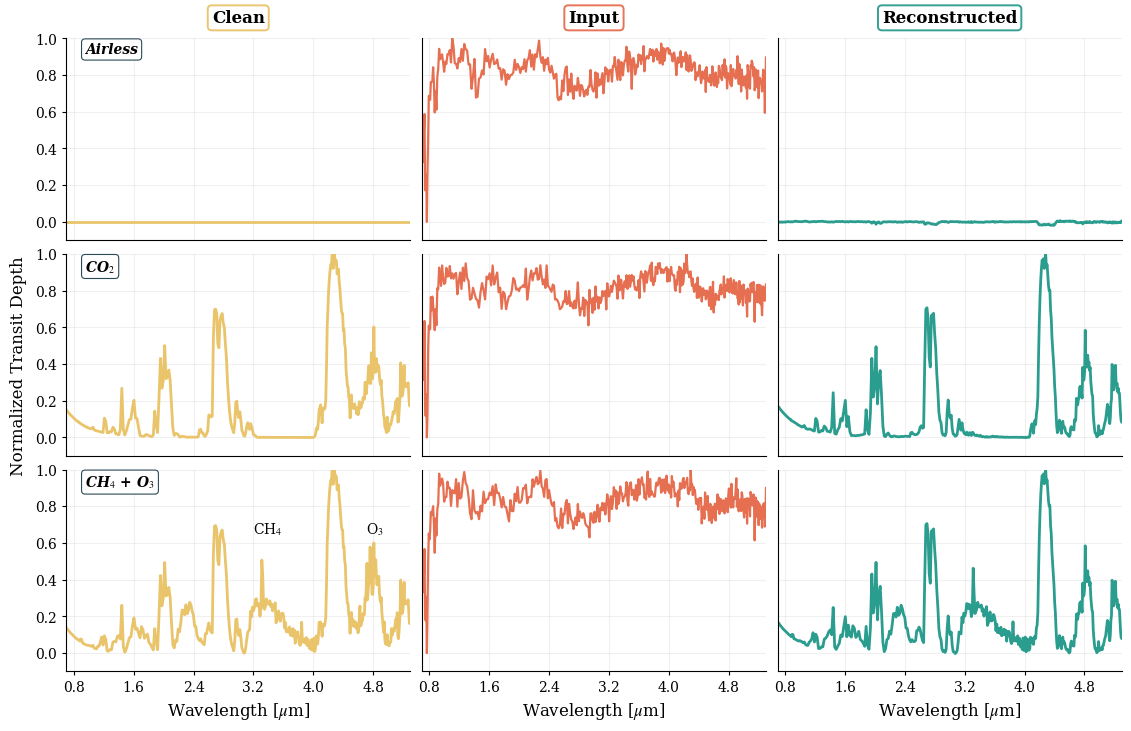

In [23]:
PALETTE = {
    "ink": "#264653",
    "teal": "#2A9D8F",  # Reconstructed
    "sand": "#E9C46A",  # Clean
    "apricot": "#F4A261",
    "tomato": "#E76F51",  # Input
}

clean_color = PALETTE["sand"]
input_color = PALETTE["tomato"]
reconstructed_color = PALETTE["teal"]

X_clean = np.asarray(X_clean, dtype=object)
X_noisy = np.asarray(X_noisy, dtype=object)
X_reconstructed = np.asarray(X_reconstructed, dtype=object)
waves = np.asarray(waves)

num_samples = 3
indices = [0, 1, 2]
row_labels = ["Airless", r"CO$_2$", r"CH$_4$ + O$_3$"]
col_labels = ["Clean", "Input", "Reconstructed"]
title_colors = [clean_color, input_color, reconstructed_color]

x = waves[::-1]


def _style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8)
    ax.grid(True, axis="both", alpha=0.18, linewidth=0.8)
    ax.margins(x=0)


def _boxed_col_title(ax, text, edge_color):
    ax.text(
        0.5,
        1.06,
        text,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        color="black",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.24",
            fc="white",
            ec=edge_color,
            lw=1.4,
            alpha=0.96,
        ),
        clip_on=False,
    )


fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(11.2, 7.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for j in range(3):
    _boxed_col_title(axes[0, j], col_labels[j], title_colors[j])

for i, idx in enumerate(indices):
    axes[i, 0].plot(x, X_clean[idx], color=clean_color, lw=2.0)
    axes[i, 1].plot(x, X_noisy[idx], color=input_color, lw=1.6)
    axes[i, 2].plot(x, X_reconstructed[idx], color=reconstructed_color, lw=2.0)

    for j in range(3):
        _style_axis(axes[i, j])
        axes[i, j].set_ylim(-0.1, 1.0)

    row_badge_x = 0.055
    axes[i, 0].text(
        row_badge_x,
        0.98,
        row_labels[i],
        transform=axes[i, 0].transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontstyle="italic",
        fontweight="semibold",
        bbox=dict(
            boxstyle="round,pad=0.26",
            fc="white",
            ec=PALETTE["ink"],
            lw=0.8,
            alpha=0.98,
        ),
    )

    if i == 2:
        axes[i, 0].text(3.2, 0.65, r"CH$_4$", fontsize=10, color="black")
        axes[i, 0].text(4.7, 0.65, r"O$_3$", fontsize=10, color="black")

    if i < num_samples - 1:
        for j in range(3):
            axes[i, j].tick_params(bottom=False, labelbottom=False)

for j in (1, 2):
    for i in range(num_samples):
        axes[i, j].tick_params(left=False, labelleft=False)

for ax in axes[-1, :]:
    ax.set_xlabel(r"Wavelength [$\mu$m]", fontsize=12)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

try:
    fig.supylabel("Normalized Transit Depth", fontsize=12)
except AttributeError:
    fig.text(
        0.03,
        0.5,
        "Normalized Transit Depth",
        rotation="vertical",
        va="center",
        ha="center",
        fontsize=12,
    )

plt.savefig("plots/autoencoder.svg", format="svg", dpi=500)
plt.savefig("plots/autoencoder.pdf", format="pdf", dpi=500)
plt.show()